In [1]:
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import seaborn as sns
import matplotlib.pyplot as plt
import re

In [2]:
# 1. Locate folders
run_dirs = glob.glob("runs/*_MIL_Task2_*")
summary_list = []
all_preds = []

print(f"Found {len(run_dirs)} folders. Starting data extraction...\n")

for d in run_dirs:
    match = re.search(r'_ID(\d+)_', d)
    if not match:
        print(f"Warning: Could not find ID in folder name: {d}")
        continue
    
    actual_id = int(match.group(1))
    split_id = (actual_id // 10) + 1
    
    # 2. read data from results.txt
    res_path = os.path.join(d, "results.txt")
    if os.path.exists(res_path):
        with open(res_path, 'r') as f:
            content = f.read()
            try:
                # get seed from results.txt
                seed = content.split("Seed:")[1].split("\n")[0].strip()
                val_loss = content.split("Best Val Loss:")[1].split("\n")[0].strip()
                test_acc = content.split("Test Accuracy:")[1].split("\n")[0].strip()
                
                summary_list.append({
                    'actual_id': actual_id,  
                    'split': f"Split {split_id}",
                    'seed': int(seed), 
                    'best_val_loss': float(val_loss),
                    'test_acc': float(test_acc),
                    'folder': os.path.basename(d)
                })
            except Exception as e:
                print(f"Error parsing results in {d}: {e}")
                continue

    # Get predictions for Consistency and Probability boxplots
    pred_path = os.path.join(d, "predictions.csv")
    if os.path.exists(pred_path):
        try:
            df_p = pd.read_csv(pred_path)
            df_p['split'] = split_id
            df_p['actual_id'] = actual_id
            all_preds.append(df_p)
        except Exception as e:
            print(f"Error reading predictions in {d}: {e}")

# summarize
df_summary = pd.DataFrame(summary_list)

if not df_summary.empty:
    df_summary = df_summary.sort_values('actual_id').reset_index(drop=True)

df_all_preds = pd.concat(all_preds) if all_preds else pd.DataFrame()

print(f"\nSuccessfully processed {len(df_summary)} folders.")
print(df_summary[['actual_id', 'split', 'seed', 'test_acc']].head(15))

Found 50 folders. Starting data extraction...


Successfully processed 50 folders.
    actual_id    split  seed  test_acc
0           0  Split 1    10    0.9444
1           1  Split 1    20    0.8889
2           2  Split 1    30    0.9444
3           3  Split 1    40    0.8889
4           4  Split 1    50    0.9444
5           5  Split 1    60    0.8889
6           6  Split 1    70    0.8889
7           7  Split 1    80    0.8333
8           8  Split 1    90    0.8889
9           9  Split 1   100    0.8889
10         10  Split 2    10    0.8421
11         11  Split 2    20    0.8421
12         12  Split 2    30    0.7895
13         13  Split 2    40    0.7895
14         14  Split 2    50    0.8421


In [3]:
df_summary.head()

,actual_id,split,seed,best_val_loss,test_acc,folder
0,0,Split 1,10,0.1418,0.9444,20260312_160914_MIL_Task2_ID0_Seed10
1,1,Split 1,20,0.0319,0.8889,20260312_160914_MIL_Task2_ID1_Seed20
2,2,Split 1,30,0.1584,0.9444,20260312_160914_MIL_Task2_ID2_Seed30
3,3,Split 1,40,0.1872,0.8889,20260312_160914_MIL_Task2_ID3_Seed40
4,4,Split 1,50,0.0603,0.9444,20260312_160914_MIL_Task2_ID4_Seed50


In [4]:
df_all_preds.head()

,case_id,true_label,predicted_label,correct,prob_class0,prob_class1,split,actual_id
0,7,1,1,True,5.511316e-09,1.000000,3,27
1,15,1,1,True,6.713946e-03,0.993286,3,27
2,22,0,0,True,9.998674e-01,0.000133,3,27
3,28,0,0,True,9.995955e-01,0.000405,3,27
4,38,1,1,True,2.777217e-05,0.999972,3,27


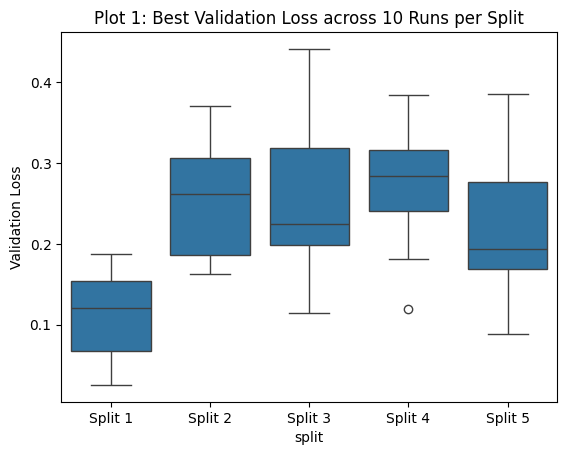

In [5]:
# plot1: Best Validation Loss: 
# For each of the five splits, 
# plot a boxplot of the best validation loss obtained across the 10 runs
sns.boxplot(data=df_summary, x='split', y='best_val_loss')
plt.title("Plot 1: Best Validation Loss across 10 Runs per Split")
plt.ylabel("Validation Loss")
plt.show()

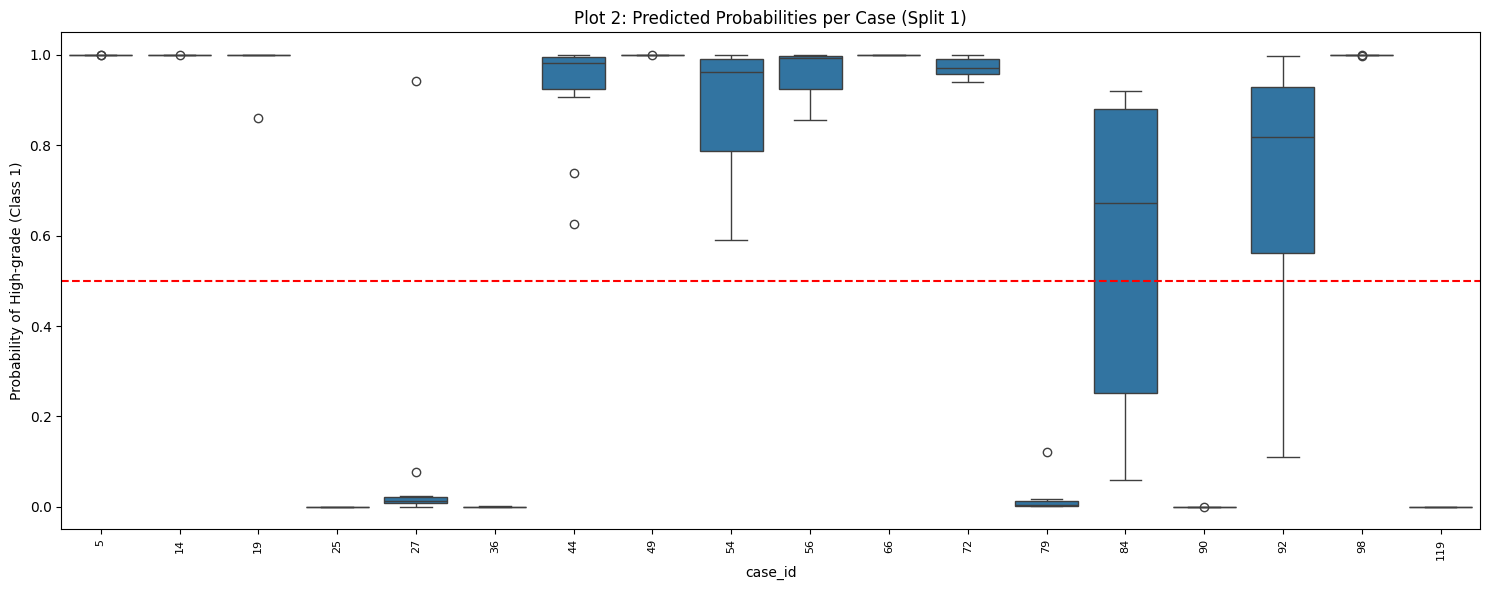

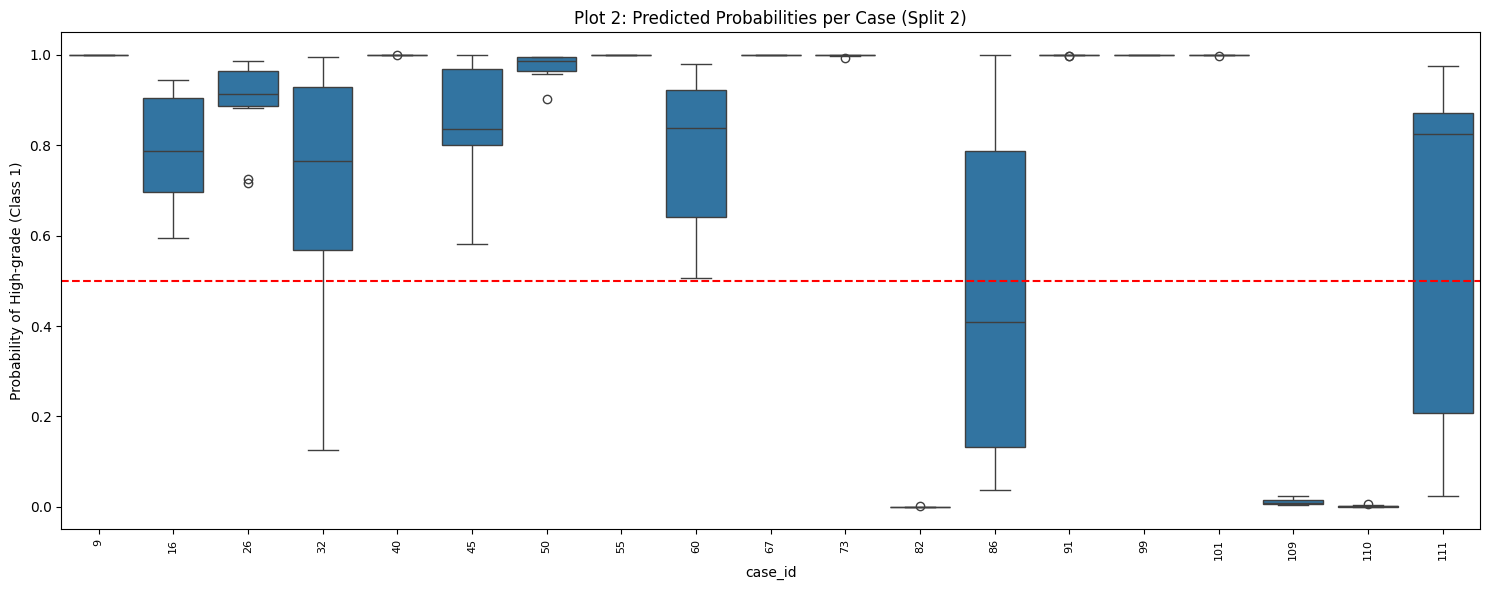

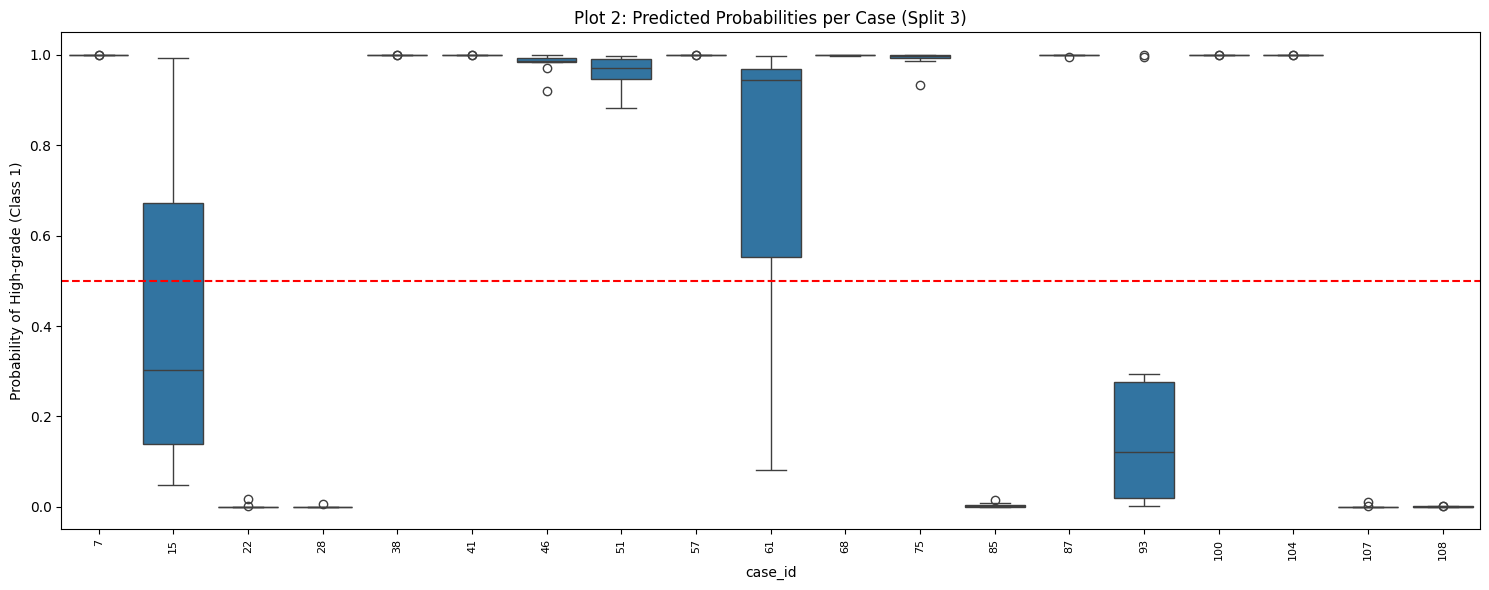

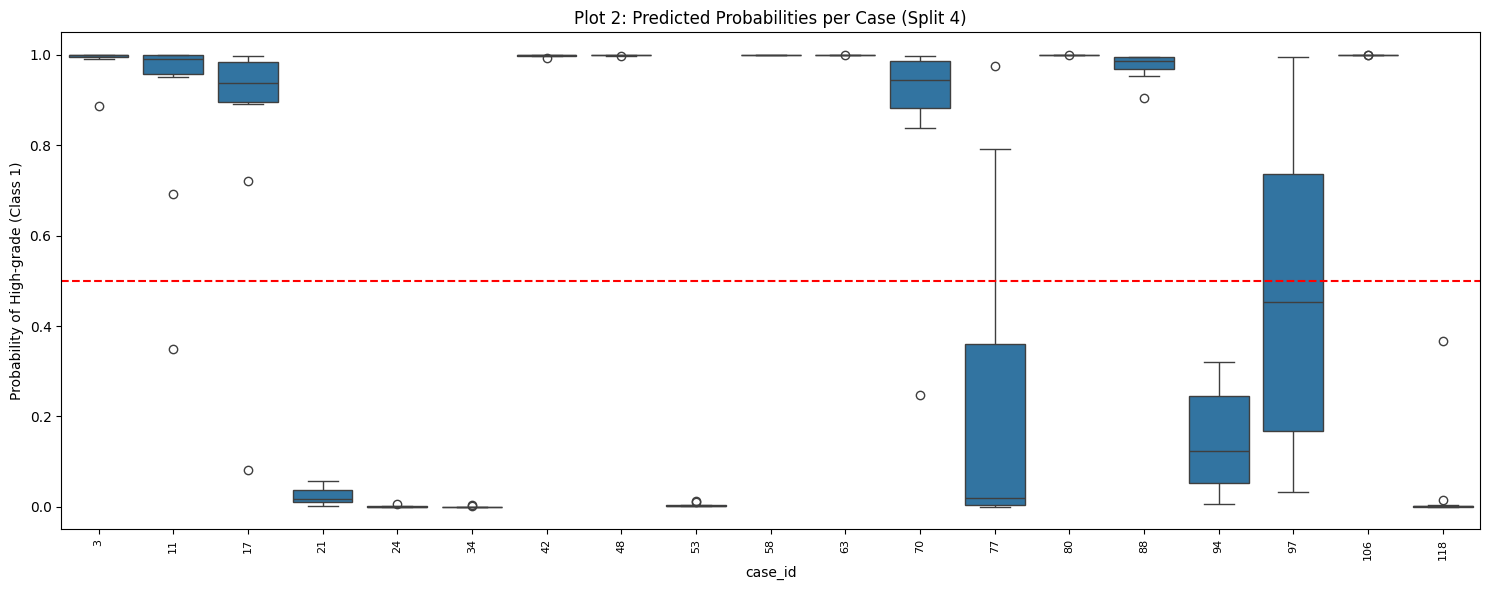

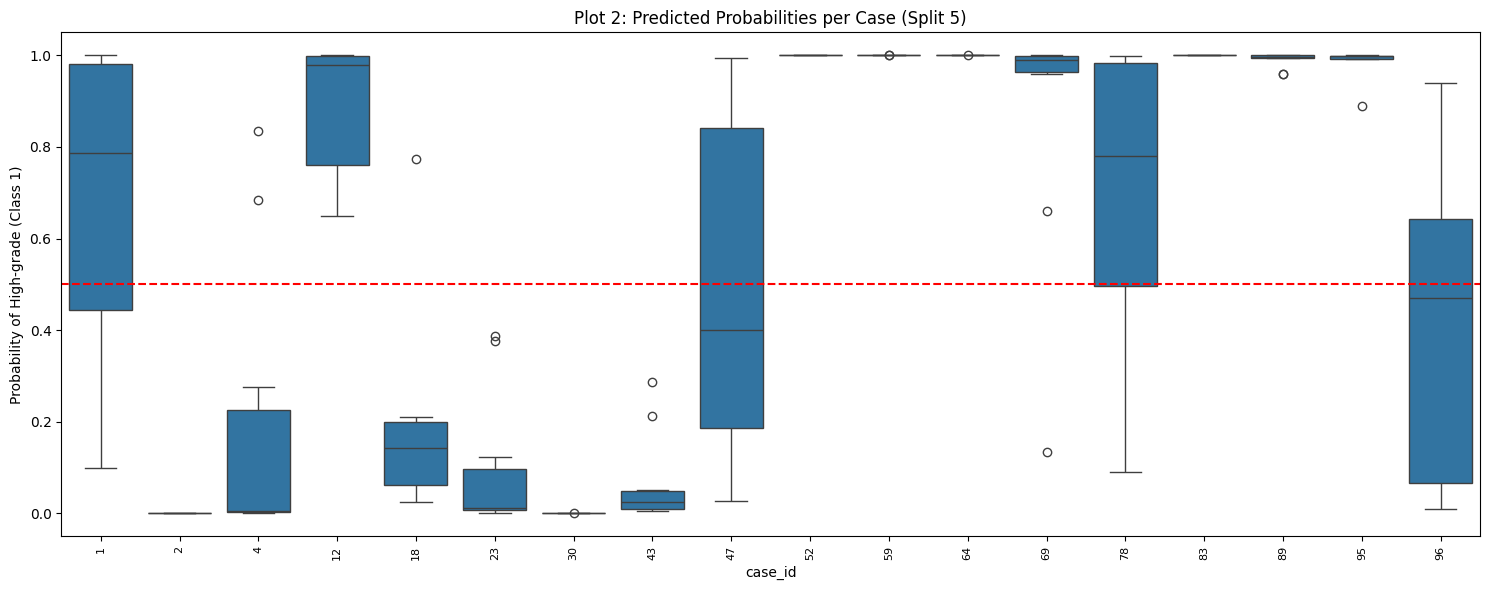

In [11]:
# plot2: Predicted Probabilities: 
# For each test case, plot a boxplot of the predicted probability across the 10 runs
# (within each of the five splits).
    
    
# Iterate through all 5 splits
for i in range(1, 6):
    # Filter data for the current split
    split_preds = df_all_preds[df_all_preds['split'] == i]
    
    # Check if the split has data to avoid empty plots
    if not split_preds.empty:
        plt.figure(figsize=(15, 6))
        
        # Plot boxplot for the current split
        sns.boxplot(
            data=split_preds.sort_values('case_id'), 
            x='case_id', 
            y='prob_class1'
        )
        
        # Standardize Y-axis label for better understanding
        plt.ylabel("Probability of High-grade (Class 1)") 
        
        # Add the decision threshold at 0.5
        plt.axhline(y=0.5, color='red', linestyle='--', label='Decision Threshold')
        
        # Dynamic title for each split
        plt.title(f"Plot 2: Predicted Probabilities per Case (Split {i})")
        
        # Rotate X-axis labels for readability
        plt.xticks(rotation=90, fontsize=8)
        
        plt.tight_layout()
        plt.show()
    else:
        print(f"No data found for Split {i}")

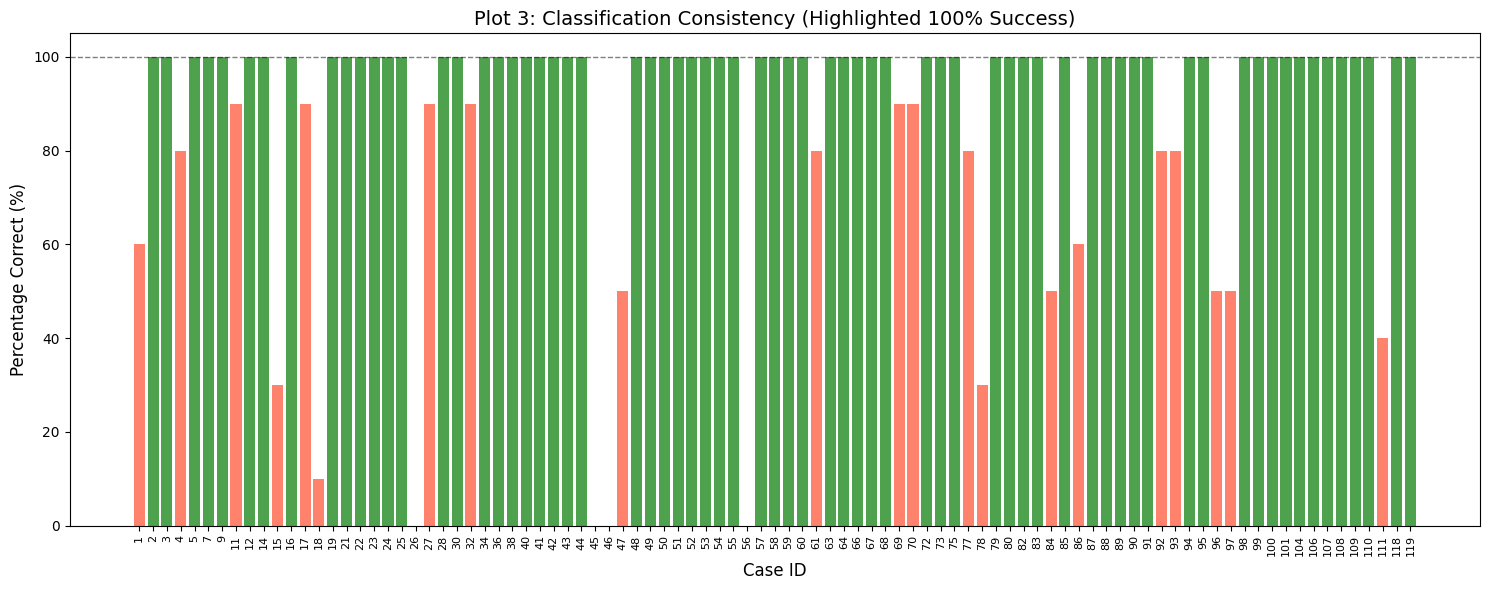

In [12]:
# plot3: Classification Consistency: 
# For each case, report the percentage of runs (out of 10) in which the case was classified correctly, 
# considering only the runs where that case appeared in the test set.

# 1. Calculate the consistency percentage for each case
consistency = df_all_preds.groupby('case_id')['correct'].mean() * 100

# 2. Define conditional colors: 
# Green for perfect consistency (100%), Tomato red for any variability (<100%)
colors = ['forestgreen' if val == 100 else 'tomato' for val in consistency]

plt.figure(figsize=(15, 6))

# 3. Create the bar chart
plt.bar(consistency.index.astype(str), consistency.values, color=colors, alpha=0.8)

# 4. Add a reference line at the 100% mark
plt.axhline(100, color='black', linestyle='--', linewidth=1, alpha=0.5)

# 5. Formatting and Labels
plt.title("Plot 3: Classification Consistency (Highlighted 100% Success)", fontsize=14)
plt.ylabel("Percentage Correct (%)", fontsize=12)
plt.xlabel("Case ID", fontsize=12)
plt.xticks(rotation=90, fontsize=8)

plt.tight_layout()
plt.show()

In [13]:
# plot4: Accuracy Variability: 
# For each of the five test datasets, 
# report the maximum and minimum test accuracy obtained across the 10 runs.

variability = df_summary.groupby('split')['test_acc'].agg(['min', 'max']).reset_index()

print("Numerical Summary of Accuracy Variability:")
print(variability)

Numerical Summary of Accuracy Variability:
     split     min     max
0  Split 1  0.8333  0.9444
1  Split 2  0.7895  0.8947
2  Split 3  0.8421  0.9474
3  Split 4  0.8947  1.0000
4  Split 5  0.7778  0.8889
